# Day 4 — SMOTE Minority-Class Experiment

This notebook is **Day 4 only**. It does not change Day 1–3 notebooks or raw data files.

KDDTest+ is loaded for a **final** evaluation at the end. It is **not** used to fit preprocessing, to run SMOTE, or to choose which experiment to keep.

## 4.1 Objective

Day 2 and Day 3 showed that **R2L** and **U2R** are hard to detect. Those classes have very few training rows. Accuracy can look reasonable while minority recall stays low.

**Day 4 question:** does **SMOTE** (Synthetic Minority Over-sampling Technique) on the model-fitting data improve minority-class learning for the five-class `attack_category` target (Normal, DoS, Probe, R2L, U2R)?

SMOTE creates **synthetic** minority examples in feature space. It is not the same as `class_weight="balanced"` (which only reweights existing rows).

We compare:

1. Logistic Regression **without** SMOTE (control), fit on `X_train_fit` / `y_train_fit`
2. Logistic Regression **with** SMOTE, applied only after preprocessing of `X_train_fit`

Both are judged on an untouched **validation** split. Only then is the selected setup scored on untouched **KDDTest+**. No SMOTE hyperparameter search. No `pip` install.

## 4.2 Imports

Only packages already in the project environment. `imblearn` is the import name for imbalanced-learn.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

from imblearn.over_sampling import SMOTE

# 4.1 Data and Object Verification

**Checkpoint 1.** Inspect whether these objects already exist in **this notebook’s kernel**:

`X_train`, `y_train`, `X_test`, `y_test`, `numerical_features`, `categorical_features`, `category_order`

Jupyter kernels do **not** share variables with `01_eda.ipynb` or `02_baseline_model.ipynb`. This cell does **not** load files, fit a model, apply SMOTE, or score KDDTest+.

If anything is missing, it **stops** and names the missing objects. It does **not** recreate them.

In [9]:
required_objects = [
    "X_train",
    "y_train",
    "X_test",
    "y_test",
    "numerical_features",
    "categorical_features",
    "category_order",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    print("Checkpoint 1 STOPPED. Required objects are missing in this kernel.")
    print("Missing:")
    for name in missing_objects:
        print(f"  - {name}")
    print()
    print("Present:")
    for name in required_objects:
        if name not in missing_objects:
            print(f"  - {name}")
    print()
    print("Do not recreate these objects in this checkpoint. Stop here.")
    print("Later cells in this notebook can load NSL-KDD; this cell will not.")
else:
    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)
    print("X_test shape:", X_test.shape)
    print("y_test shape:", y_test.shape)
    print()

    print("Numerical features:", len(numerical_features))
    print("Categorical features:", len(categorical_features))
    print("Category order:", category_order)
    print()

    print("Training class counts:")
    display(y_train.value_counts().reindex(category_order))

    print()
    print("Test class counts:")
    display(y_test.value_counts().reindex(category_order))

    print()
    print("Missing values:")
    print("X_train:", X_train.isna().sum().sum())
    print("X_test:", X_test.isna().sum().sum())
    print("y_train:", y_train.isna().sum())
    print("y_test:", y_test.isna().sum())

X_train shape: (125973, 41)
y_train shape: (125973,)
X_test shape: (22544, 41)
y_test shape: (22544,)

Numerical features: 38
Categorical features: 3
Category order: ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

Training class counts:


attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


Test class counts:


attack_category
Normal    9711
DoS       7460
Probe     2421
R2L       2885
U2R         67
Name: count, dtype: int64


Missing values:
X_train: 0
X_test: 0
y_train: 0
y_test: 0


# 4.2 Inspect Current Preprocessing

**Checkpoint 2.** Inspect the **existing** Day 4 no-SMOTE Logistic Regression pipeline (`lr_no_smote_pipeline`) that produced the validation control.

This cell does **not** create a new preprocessor, does **not** refit, does **not** import or use `imblearn`, does **not** apply SMOTE, and does **not** score KDDTest+.

If `lr_no_smote_pipeline` is not in this kernel yet, the cell reports that and **stops**.

In [10]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

if "lr_no_smote_pipeline" not in globals():
    print("Checkpoint 2 STOPPED.")
    print("lr_no_smote_pipeline is not available in this kernel.")
    print("Run the Day 4 no-SMOTE Logistic Regression cell first.")
    print("This checkpoint will not create or fit a preprocessor.")
else:
    current_preprocessor = lr_no_smote_pipeline.named_steps["preprocess"]

    num_names = list(numerical_features)
    cat_names = list(categorical_features)

    print("1. Feature counts")
    print("   Numerical features:", len(num_names))
    print("   Categorical features:", len(cat_names))
    print()
    print("2. Categorical feature names:")
    print("  ", cat_names)
    print()
    print("3. Numerical feature names:")
    print("  ", num_names)
    print()

    named_transformers = dict(current_preprocessor.named_transformers_)
    numerical_transformer = named_transformers.get("num")
    categorical_transformer = named_transformers.get("cat")

    print("4. Preprocessing type")
    print("   Numerical features:", type(numerical_transformer).__name__)
    print("   Categorical features:", type(categorical_transformer).__name__)
    print()

    uses_scaler = isinstance(numerical_transformer, StandardScaler)
    uses_ohe = isinstance(categorical_transformer, OneHotEncoder)
    print("5. StandardScaler used:", uses_scaler)
    print("6. OneHotEncoder used:", uses_ohe)

    if uses_ohe:
        unknown_setting = categorical_transformer.handle_unknown
        print("7. OneHotEncoder handle_unknown:", unknown_setting)
        print("   Handles unknown categories:", unknown_setting == "ignore")
    else:
        print("7. OneHotEncoder handle_unknown: (encoder not found)")

    n_transformed = len(current_preprocessor.get_feature_names_out())
    print()
    print("8. Transformed feature count from the fitted preprocessing stage:")
    print("  ", n_transformed)
    print()
    print("Inspected object: lr_no_smote_pipeline.named_steps['preprocess']")
    print("No refit. No SMOTE. KDDTest+ was not evaluated.")

1. Feature counts
   Numerical features: 38
   Categorical features: 3

2. Categorical feature names:
   ['protocol_type', 'service', 'flag']

3. Numerical feature names:
   ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

4. Preprocessing type
   Numerical features: StandardScaler
   Categorical features: OneHotEncoder

5. StandardScaler used: True
6. 

## 4.3 Recreate/load the NSL-KDD data

Same 43 column names and five-class map as Days 1–3. Train and test stay in **separate** DataFrames. KDDTest+ is not mixed into training.

In [11]:
COLUMNS = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty",
]

attack_category_map = {
    "normal": "Normal",
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "apache2": "DoS",
    "udpstorm": "DoS",
    "processtable": "DoS",
    "mailbomb": "DoS",
    "worm": "DoS",
    "satan": "Probe",
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "mscan": "Probe",
    "saint": "Probe",
    "guess_passwd": "R2L",
    "ftp_write": "R2L",
    "imap": "R2L",
    "phf": "R2L",
    "multihop": "R2L",
    "warezmaster": "R2L",
    "warezclient": "R2L",
    "spy": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "snmpguess": "R2L",
    "snmpgetattack": "R2L",
    "httptunnel": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "rootkit": "U2R",
    "perl": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
    "ps": "U2R",
}

category_order = ["Normal", "DoS", "Probe", "R2L", "U2R"]

train_df = pd.read_csv("../data/raw/KDDTrain+.txt", header=None, names=COLUMNS)
test_df = pd.read_csv("../data/raw/KDDTest+.txt", header=None, names=COLUMNS)

train_df["attack_category"] = train_df["label"].map(attack_category_map)
test_df["attack_category"] = test_df["label"].map(attack_category_map)

feature_columns = [col for col in COLUMNS if col not in ["label", "difficulty"]]
categorical_features = ["protocol_type", "service", "flag"]
numerical_features = [col for col in feature_columns if col not in categorical_features]

X_train = train_df[feature_columns]
y_train = train_df["attack_category"]
X_test = test_df[feature_columns]
y_test = test_df["attack_category"]

print("KDDTrain+ X:", X_train.shape, "y:", y_train.shape)
print("KDDTest+  X:", X_test.shape, "y:", y_test.shape)
print("KDDTest+ is held out. It will not be used until section 4.11.")

KDDTrain+ X: (125973, 41) y: (125973,)
KDDTest+  X: (22544, 41) y: (22544,)
KDDTest+ is held out. It will not be used until section 4.11.


## 4.4 Train/validation split

Split **KDDTrain+ only** into 80% fitting data and 20% validation. Stratify on `y_train` so class proportions stay similar. KDDTest+ is not an argument to `train_test_split`.

In [12]:
X_train_fit, X_validation, y_train_fit, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42,
)

print("X_train_fit:", X_train_fit.shape)
print("X_validation:", X_validation.shape)
print("y_train_fit:", y_train_fit.shape)
print("y_validation:", y_validation.shape)
print()
print("y_train_fit counts:")
display(y_train_fit.value_counts().reindex(category_order))
print("y_train_fit percentages:")
display((y_train_fit.value_counts(normalize=True).reindex(category_order) * 100).round(4))
print("y_validation counts:")
display(y_validation.value_counts().reindex(category_order))
print("y_validation percentages:")
display((y_validation.value_counts(normalize=True).reindex(category_order) * 100).round(4))
print("KDDTest+ still:", X_test.shape, y_test.shape)

X_train_fit: (100778, 41)
X_validation: (25195, 41)
y_train_fit: (100778,)
y_validation: (25195,)

y_train_fit counts:


attack_category
Normal    53874
DoS       36741
Probe      9325
R2L         796
U2R          42
Name: count, dtype: int64

y_train_fit percentages:


attack_category
Normal    53.4581
DoS       36.4574
Probe      9.2530
R2L        0.7899
U2R        0.0417
Name: proportion, dtype: float64

y_validation counts:


attack_category
Normal    13469
DoS        9186
Probe      2331
R2L         199
U2R          10
Name: count, dtype: int64

y_validation percentages:


attack_category
Normal    53.4590
DoS       36.4596
Probe      9.2518
R2L        0.7898
U2R        0.0397
Name: proportion, dtype: float64

KDDTest+ still: (22544, 41) (22544,)


## 4.5 Preprocessing

Same design as the Day 2 baseline:

- `protocol_type`, `service`, `flag` → `OneHotEncoder(handle_unknown="ignore")`
- remaining numeric features → `StandardScaler`
- `ColumnTransformer` inside a sklearn `Pipeline` for the **no-SMOTE** control

Each experiment gets its **own** transformer instance so one `.fit` does not overwrite the other.

Fit preprocessing **only** on `X_train_fit`. Validation and test are transformed with that fitted object, never used to estimate means, scales, or one-hot categories.

In [13]:
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", StandardScaler(), numerical_features),
        ]
    )


def evaluate_split(title, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p = precision_score(y_true, y_pred, average="macro", labels=category_order, zero_division=0)
    r = recall_score(y_true, y_pred, average="macro", labels=category_order, zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", labels=category_order, zero_division=0)
    print(title)
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro precision: {p:.4f}")
    print(f"Macro recall:    {r:.4f}")
    print(f"Macro F1:        {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, labels=category_order, digits=4, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=category_order)
    cm_df = pd.DataFrame(cm, index=category_order, columns=category_order)
    print("Confusion matrix (rows = actual, columns = predicted):")
    display(cm_df)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    prec, rec, f1s, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=category_order, zero_division=0
    )
    per_class = pd.DataFrame(
        {"precision": prec, "recall": rec, "f1": f1s},
        index=category_order,
    )
    return {
        "accuracy": acc,
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
        "per_class": per_class,
    }

## 4.6 Important SMOTE design note

SMOTE interpolates between **numeric** neighbor vectors. It cannot be applied to raw NSL-KDD rows that still contain strings (`tcp`, `http`, `SF`).

**Order that avoids leakage:**

1. Fit the encoder/scaler on **`X_train_fit` only**.
2. Transform `X_train_fit` into a numeric matrix.
3. Run `SMOTE` on that matrix and `y_train_fit` only → `X_resampled`, `y_resampled`.
4. Train Logistic Regression on the resampled fitting data.
5. Transform **validation** (and later test) with the **already fitted** preprocessor. **Do not** run SMOTE on them.

Synthetic rows must **never** enter validation or KDDTest+. Those sets stay real traffic for honest scores. If SMOTE saw validation or test, minority metrics would be optimistic and leaked.

## 4.7 Baseline control (no SMOTE)

Logistic Regression on `X_train_fit` / `y_train_fit` with the same preprocess-then-classify pipeline. **No** SMOTE. **No** `class_weight` here so the contrast is SMOTE vs not SMOTE.

Evaluate **only** on `X_validation` / `y_validation`.

Validation — Logistic Regression, no SMOTE
Accuracy:        0.9889
Macro precision: 0.9420
Macro recall:    0.8216
Macro F1:        0.8560

              precision    recall  f1-score   support

      Normal     0.9888    0.9917    0.9903     13469
         DoS     0.9965    0.9979    0.9972      9186
       Probe     0.9807    0.9597    0.9701      2331
         R2L     0.7438    0.7588    0.7512       199
         U2R     1.0000    0.4000    0.5714        10

    accuracy                         0.9889     25195
   macro avg     0.9420    0.8216    0.8560     25195
weighted avg     0.9889    0.9889    0.9889     25195

Confusion matrix (rows = actual, columns = predicted):


,Normal,DoS,Probe,R2L,U2R
Normal,13357,24,42,46,0
DoS,17,9167,2,0,0
Probe,84,7,2237,3,0
R2L,47,1,0,151,0
U2R,3,0,0,3,4


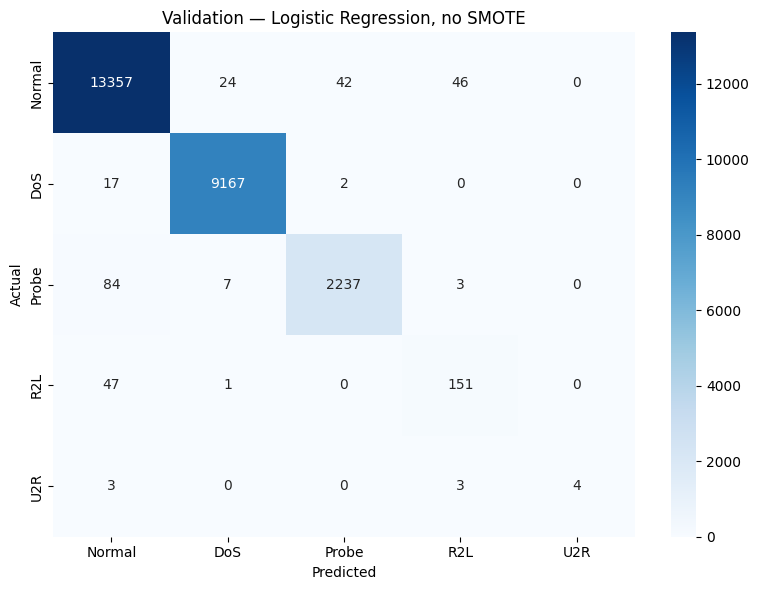

In [14]:
lr_no_smote_pipeline = Pipeline(
    [
        ("preprocess", make_preprocessor()),
        (
            "classifier",
            LogisticRegression(max_iter=2000, random_state=42),
        ),
    ]
)

lr_no_smote_pipeline.fit(X_train_fit, y_train_fit)
y_val_no_smote_pred = lr_no_smote_pipeline.predict(X_validation)

no_smote_metrics = evaluate_split(
    "Validation — Logistic Regression, no SMOTE",
    y_validation,
    y_val_no_smote_pred,
)

## 4.8 SMOTE Logistic Regression

Preprocess `X_train_fit` → SMOTE (`random_state=42`) → Logistic Regression (`max_iter=2000`, `random_state=42`).

Validation is transformed with the same preprocessor and **not** oversampled.

Validation — Logistic Regression, SMOTE on fitting data only
Accuracy:        0.9698
Macro precision: 0.6616
Macro recall:    0.9313
Macro F1:        0.7028

              precision    recall  f1-score   support

      Normal     0.9966    0.9483    0.9718     13469
         DoS     0.9961    0.9986    0.9973      9186
       Probe     0.9314    0.9850    0.9575      2331
         R2L     0.3292    0.9246    0.4855       199
         U2R     0.0544    0.8000    0.1019        10

    accuracy                         0.9698     25195
   macro avg     0.6616    0.9313    0.7028     25195
weighted avg     0.9848    0.9698    0.9756     25195

Confusion matrix (rows = actual, columns = predicted):


,Normal,DoS,Probe,R2L,U2R
Normal,12772,31,167,371,128
DoS,10,9173,2,1,0
Probe,27,4,2296,2,2
R2L,5,1,0,184,9
U2R,1,0,0,1,8


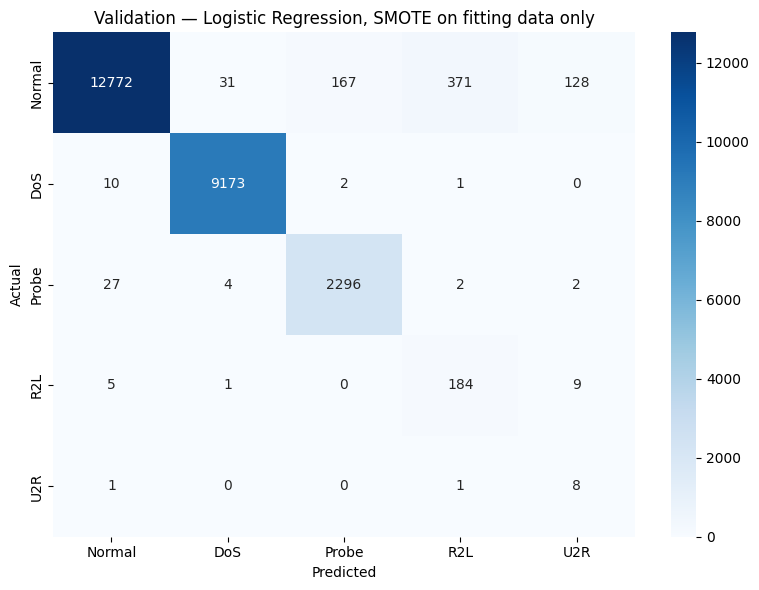

SMOTE was called only with processed X_train_fit and y_train_fit.
Validation rows were transformed, not resampled.


In [15]:
smote_preprocessor = make_preprocessor()
X_train_fit_processed = smote_preprocessor.fit_transform(X_train_fit)
X_validation_processed = smote_preprocessor.transform(X_validation)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_fit_processed, y_train_fit)

lr_smote = LogisticRegression(max_iter=2000, random_state=42)
lr_smote.fit(X_resampled, y_resampled)
y_val_smote_pred = lr_smote.predict(X_validation_processed)

smote_metrics = evaluate_split(
    "Validation — Logistic Regression, SMOTE on fitting data only",
    y_validation,
    y_val_smote_pred,
)

print("SMOTE was called only with processed X_train_fit and y_train_fit.")
print("Validation rows were transformed, not resampled.")

## 4.9 Compare class distributions

SMOTE should change **fitting** counts (typically equalizing classes). Validation counts and KDDTest+ must stay the same. KDDTest+ is never passed to `fit_resample`.

In [16]:
print("Class counts BEFORE SMOTE (y_train_fit):")
display(y_train_fit.value_counts().reindex(category_order))

print("Class counts AFTER SMOTE (y_resampled):")
display(pd.Series(y_resampled).value_counts().reindex(category_order))

print("Validation class counts (must match section 4.4, not SMOTE):")
display(y_validation.value_counts().reindex(category_order))

print("KDDTest+ class counts (never passed to SMOTE):")
display(y_test.value_counts().reindex(category_order))

print("X_resampled shape:", np.shape(X_resampled), "y_resampled shape:", np.shape(y_resampled))
print("X_validation shape (unchanged by SMOTE):", X_validation.shape)
print("X_test shape (unchanged, not passed to SMOTE):", X_test.shape)
print("Confirmed: smote.fit_resample received only the processed fitting matrix.")

Class counts BEFORE SMOTE (y_train_fit):


attack_category
Normal    53874
DoS       36741
Probe      9325
R2L         796
U2R          42
Name: count, dtype: int64

Class counts AFTER SMOTE (y_resampled):


attack_category
Normal    53874
DoS       53874
Probe     53874
R2L       53874
U2R       53874
Name: count, dtype: int64

Validation class counts (must match section 4.4, not SMOTE):


attack_category
Normal    13469
DoS        9186
Probe      2331
R2L         199
U2R          10
Name: count, dtype: int64

KDDTest+ class counts (never passed to SMOTE):


attack_category
Normal    9711
DoS       7460
Probe     2421
R2L       2885
U2R         67
Name: count, dtype: int64

X_resampled shape: (269370, 122) y_resampled shape: (269370,)
X_validation shape (unchanged by SMOTE): (25195, 41)
X_test shape (unchanged, not passed to SMOTE): (22544, 41)
Confirmed: smote.fit_resample received only the processed fitting matrix.


## 4.10 Minority-class analysis

Compare **validation** no-SMOTE vs SMOTE for R2L, U2R, and Macro F1.

SMOTE often **raises minority recall** (more synthetic rare examples during fitting) and can **lower precision** (more false positives). Macro F1 balances those. Look at the table after you run the cell; do not assume SMOTE wins.

In [17]:
minority_comparison = pd.DataFrame(
    {
        "Metric": [
            "R2L precision",
            "R2L recall",
            "R2L F1",
            "U2R precision",
            "U2R recall",
            "U2R F1",
            "Macro F1",
        ],
        "No SMOTE (validation)": [
            no_smote_metrics["per_class"].loc["R2L", "precision"],
            no_smote_metrics["per_class"].loc["R2L", "recall"],
            no_smote_metrics["per_class"].loc["R2L", "f1"],
            no_smote_metrics["per_class"].loc["U2R", "precision"],
            no_smote_metrics["per_class"].loc["U2R", "recall"],
            no_smote_metrics["per_class"].loc["U2R", "f1"],
            no_smote_metrics["macro_f1"],
        ],
        "SMOTE (validation)": [
            smote_metrics["per_class"].loc["R2L", "precision"],
            smote_metrics["per_class"].loc["R2L", "recall"],
            smote_metrics["per_class"].loc["R2L", "f1"],
            smote_metrics["per_class"].loc["U2R", "precision"],
            smote_metrics["per_class"].loc["U2R", "recall"],
            smote_metrics["per_class"].loc["U2R", "f1"],
            smote_metrics["macro_f1"],
        ],
    }
)
minority_comparison["SMOTE minus no SMOTE"] = (
    minority_comparison["SMOTE (validation)"] - minority_comparison["No SMOTE (validation)"]
)
print("Validation minority-class comparison:")
display(minority_comparison.round(4))

print("Precision/recall tradeoff (read the table):")
print(
    "If SMOTE recall rises while precision falls, the model calls R2L/U2R more often "
    "(fewer misses, more false alarms). Macro F1 says whether that tradeoff helped overall."
)

Validation minority-class comparison:


,Metric,No SMOTE (validation),SMOTE (validation),SMOTE minus no SMOTE
0,R2L precision,0.7438,0.3292,-0.4147
1,R2L recall,0.7588,0.9246,0.1658
2,R2L F1,0.7512,0.4855,-0.2658
3,U2R precision,1.0000,0.0544,-0.9456
4,U2R recall,0.4000,0.8000,0.4000
5,U2R F1,0.5714,0.1019,-0.4695
6,Macro F1,0.8560,0.7028,-0.1532


Precision/recall tradeoff (read the table):
If SMOTE recall rises while precision falls, the model calls R2L/U2R more often (fewer misses, more false alarms). Macro F1 says whether that tradeoff helped overall.


## 4.11 Final test evaluation (KDDTest+)

Selection uses **validation Macro F1 only**. KDDTest+ was not used to tune SMOTE (`random_state=42` only) and is not used to pick the winner.

The chosen fitted experiment is then scored on untouched KDDTest+. These numbers are **final test evaluation**, not validation.

Selected from VALIDATION Macro F1 only: Logistic Regression (no SMOTE)
SMOTE was not tuned on KDDTest+.

FINAL TEST (KDDTest+) — Logistic Regression (no SMOTE)
Accuracy:        0.7610
Macro precision: 0.7746
Macro recall:    0.5637
Macro F1:        0.5806

              precision    recall  f1-score   support

      Normal     0.6652    0.9304    0.7758      9711
         DoS     0.9190    0.8286    0.8714      7460
       Probe     0.8778    0.7741    0.8227      2421
         R2L     0.6282    0.0170    0.0331      2885
         U2R     0.7826    0.2687    0.4000        67

    accuracy                         0.7610     22544
   macro avg     0.7746    0.5637    0.5806     22544
weighted avg     0.7676    0.7610    0.7163     22544

Confusion matrix (rows = actual, columns = predicted):


,Normal,DoS,Probe,R2L,U2R
Normal,9035,419,251,2,4
DoS,1274,6181,5,0,0
Probe,400,121,1874,26,0
R2L,2827,3,5,49,1
U2R,46,2,0,1,18


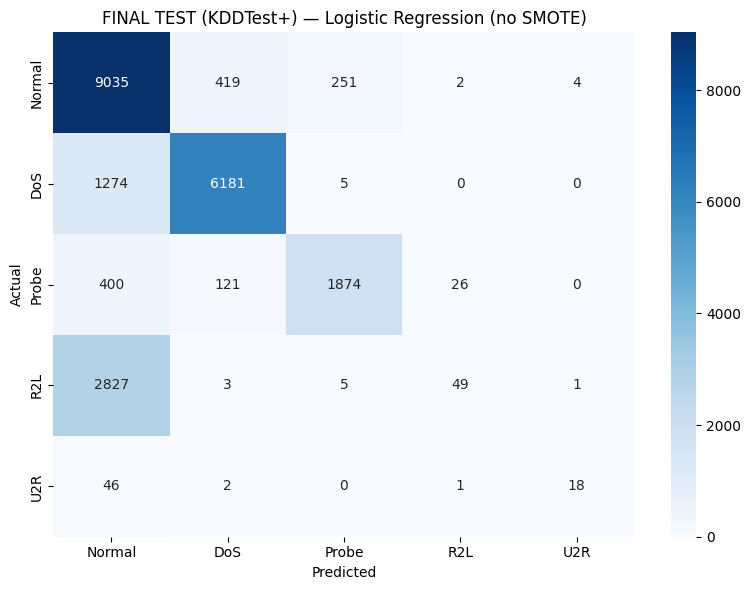

In [18]:
if smote_metrics["macro_f1"] > no_smote_metrics["macro_f1"]:
    selected_name = "SMOTE Logistic Regression"
    X_test_processed = smote_preprocessor.transform(X_test)
    y_test_pred = lr_smote.predict(X_test_processed)
else:
    selected_name = "Logistic Regression (no SMOTE)"
    y_test_pred = lr_no_smote_pipeline.predict(X_test)

print("Selected from VALIDATION Macro F1 only:", selected_name)
print("SMOTE was not tuned on KDDTest+.")
print()

test_metrics = evaluate_split(
    f"FINAL TEST (KDDTest+) — {selected_name}",
    y_test,
    y_test_pred,
)

## 4.12 Summary

After you run the cells, use the **validation** table in 4.10 (not test) to decide whether this SMOTE setup helped learning. Then treat 4.11 as a one-shot generalization check.

Answer from the printed numbers:

- Did **Macro F1** go up with SMOTE on validation?
- Did **R2L recall** go up?
- Did **U2R recall** go up?
- Did **R2L/U2R precision** go down (tradeoff)?
- Is SMOTE useful enough to **carry forward** in *this* project, with *this* Logistic Regression and default SMOTE?

The next code cell prints those comparisons from the variables already computed.

**Limits:** this is **one** experiment (no `k_neighbors` search, no other classifiers). It does **not** prove SMOTE is always better for NSL-KDD or for IDS in general.

In [19]:
def up_or_down(delta):
    if delta > 0:
        return "increased"
    if delta < 0:
        return "decreased"
    return "unchanged"


mf = smote_metrics["macro_f1"] - no_smote_metrics["macro_f1"]
r2l_r = (
    smote_metrics["per_class"].loc["R2L", "recall"]
    - no_smote_metrics["per_class"].loc["R2L", "recall"]
)
u2r_r = (
    smote_metrics["per_class"].loc["U2R", "recall"]
    - no_smote_metrics["per_class"].loc["U2R", "recall"]
)
r2l_p = (
    smote_metrics["per_class"].loc["R2L", "precision"]
    - no_smote_metrics["per_class"].loc["R2L", "precision"]
)
u2r_p = (
    smote_metrics["per_class"].loc["U2R", "precision"]
    - no_smote_metrics["per_class"].loc["U2R", "precision"]
)

print("Validation summary (this notebook's SMOTE vs no-SMOTE control):")
print(f"  Macro F1 {up_or_down(mf)} by {mf:+.4f}")
print(f"  R2L recall {up_or_down(r2l_r)} by {r2l_r:+.4f}")
print(f"  U2R recall {up_or_down(u2r_r)} by {u2r_r:+.4f}")
print(f"  R2L precision {up_or_down(r2l_p)} by {r2l_p:+.4f}")
print(f"  U2R precision {up_or_down(u2r_p)} by {u2r_p:+.4f}")
print(f"  Experiment selected for KDDTest+: {selected_name}")
print(f"  Final test Macro F1: {test_metrics['macro_f1']:.4f}")
print()
print(
    "Carry-forward: use the validation Macro F1 and minority recall/precision together. "
    "A recall gain with a large precision drop may still be a poor operating point. "
    "This is not a universal claim about SMOTE."
)

Validation summary (this notebook's SMOTE vs no-SMOTE control):
  Macro F1 decreased by -0.1532
  R2L recall increased by +0.1658
  U2R recall increased by +0.4000
  R2L precision decreased by -0.4147
  U2R precision decreased by -0.9456
  Experiment selected for KDDTest+: Logistic Regression (no SMOTE)
  Final test Macro F1: 0.5806

Carry-forward: use the validation Macro F1 and minority recall/precision together. A recall gain with a large precision drop may still be a poor operating point. This is not a universal claim about SMOTE.


## Day 4 — Validation Comparison: Class Weighting vs SMOTE

This section **does not** fit a model, apply SMOTE, change thresholds, or touch KDDTest+.

It gathers **already observed validation** scores:

- **Class-weighted Logistic Regression** — Day 3 `lr_validation_pipeline` on `y_validation` (not KDDTest+)
- **Logistic Regression — no SMOTE** — Day 4 validation control
- **Logistic Regression — SMOTE** — Day 4 validation SMOTE experiment

These numbers are for **model-selection reasoning only**. No final model is chosen here.

In [20]:
validation_comparison_df = pd.DataFrame(
    [
        {
            "Evaluation": "Class-weighted Logistic Regression",
            "Accuracy": 0.9668,
            "Macro Precision": 0.6567,
            "Macro Recall": 0.9528,
            "Macro F1": 0.6985,
            "R2L Precision": 0.3091,
            "R2L Recall": 0.9397,
            "R2L F1": 0.4652,
            "U2R Precision": 0.0577,
            "U2R Recall": 0.9000,
            "U2R F1": 0.1084,
        },
        {
            "Evaluation": "Logistic Regression — no SMOTE",
            "Accuracy": 0.9889,
            "Macro Precision": 0.9420,
            "Macro Recall": 0.8216,
            "Macro F1": 0.8560,
            "R2L Precision": 0.7438,
            "R2L Recall": 0.7588,
            "R2L F1": 0.7512,
            "U2R Precision": 1.0000,
            "U2R Recall": 0.4000,
            "U2R F1": 0.5714,
        },
        {
            "Evaluation": "Logistic Regression — SMOTE",
            "Accuracy": 0.9698,
            "Macro Precision": 0.6616,
            "Macro Recall": 0.9313,
            "Macro F1": 0.7028,
            "R2L Precision": 0.3292,
            "R2L Recall": 0.9246,
            "R2L F1": 0.4855,
            "U2R Precision": 0.0544,
            "U2R Recall": 0.8000,
            "U2R F1": 0.1019,
        },
    ]
)

print("Validation comparison (KDDTrain+ validation split only; KDDTest+ unused):")
display(validation_comparison_df)

print()
print("Highest validation Macro F1:", validation_comparison_df.loc[validation_comparison_df["Macro F1"].idxmax(), "Evaluation"])
print("Highest R2L recall:", validation_comparison_df.loc[validation_comparison_df["R2L Recall"].idxmax(), "Evaluation"])
print("Highest U2R recall:", validation_comparison_df.loc[validation_comparison_df["U2R Recall"].idxmax(), "Evaluation"])
print()
print(
    "SMOTE increases minority-class recall substantially versus no SMOTE "
    "(R2L 0.7588 → 0.9246; U2R 0.4000 → 0.8000), but it does not produce the "
    "highest overall Macro F1 in this validation experiment "
    "(SMOTE 0.7028 vs no SMOTE 0.8560)."
)
print(
    "This validation comparison is for model-selection reasoning only. "
    "No final model is selected here. KDDTest+ remains untouched in this section."
)

Validation comparison (KDDTrain+ validation split only; KDDTest+ unused):


,Evaluation,Accuracy,Macro Precision,Macro Recall,Macro F1,R2L Precision,R2L Recall,R2L F1,U2R Precision,U2R Recall,U2R F1
0,Class-weighted Logistic Regression,0.9668,0.6567,0.9528,0.6985,0.3091,0.9397,0.4652,0.0577,0.9,0.1084
1,Logistic Regression — no SMOTE,0.9889,0.9420,0.8216,0.8560,0.7438,0.7588,0.7512,1.0000,0.4,0.5714
2,Logistic Regression — SMOTE,0.9698,0.6616,0.9313,0.7028,0.3292,0.9246,0.4855,0.0544,0.8,0.1019



Highest validation Macro F1: Logistic Regression — no SMOTE
Highest R2L recall: Class-weighted Logistic Regression
Highest U2R recall: Class-weighted Logistic Regression

SMOTE increases minority-class recall substantially versus no SMOTE (R2L 0.7588 → 0.9246; U2R 0.4000 → 0.8000), but it does not produce the highest overall Macro F1 in this validation experiment (SMOTE 0.7028 vs no SMOTE 0.8560).
This validation comparison is for model-selection reasoning only. No final model is selected here. KDDTest+ remains untouched in this section.


## Day 4 — Minority-Class Error Analysis

Purpose: see the **error trade-off** between overall validation performance and R2L/U2R detection **before** a Day 4 modeling decision.

This section uses **existing validation predictions** and `y_validation` only. It does **not** fit a model, tune thresholds, pick a final model, or use **KDDTest+** (`X_test` / `y_test` are not referenced). KDDTest+ remains untouched.

In [21]:
def validation_pred_if_present(candidate_names):
    for name in candidate_names:
        if name in globals():
            return globals()[name], name
    return None, None


def minority_counts_from_cm(cm_df):
    r2l_tp = int(cm_df.loc['Actual R2L', 'Predicted R2L'])
    r2l_fn = int(cm_df.loc['Actual R2L'].sum() - r2l_tp)
    r2l_fp = int(cm_df['Predicted R2L'].sum() - r2l_tp)
    u2r_tp = int(cm_df.loc['Actual U2R', 'Predicted U2R'])
    u2r_fn = int(cm_df.loc['Actual U2R'].sum() - u2r_tp)
    u2r_fp = int(cm_df['Predicted U2R'].sum() - u2r_tp)
    return {
        'R2L true positives': r2l_tp,
        'R2L false positives': r2l_fp,
        'R2L false negatives': r2l_fn,
        'U2R true positives': u2r_tp,
        'U2R false positives': u2r_fp,
        'U2R false negatives': u2r_fn,
    }


validation_pred_sources = {
    'Class-weighted Logistic Regression': [
        'y_validation_pred',
        'lr_class_weighted_pred',
        'y_val_weighted_pred',
    ],
    'Logistic Regression without SMOTE': ['y_val_no_smote_pred'],
    'Logistic Regression with SMOTE': ['y_val_smote_pred'],
}

if 'y_validation' not in globals() or 'category_order' not in globals():
    print('STOPPED. Need y_validation and category_order in this kernel.')
    print('KDDTest+ was not used.')
else:
    error_rows = []
    for model_name, candidates in validation_pred_sources.items():
        y_pred, used_name = validation_pred_if_present(candidates)
        print('=' * 72)
        print(model_name)
        if y_pred is None:
            print('Predictions not found in this kernel. Looked for:', candidates)
            print('Not retraining. Skipping this model.')
            continue
        print('Using existing array:', used_name)
        cm = confusion_matrix(y_validation, y_pred, labels=category_order)
        cm_df = pd.DataFrame(
            cm,
            index=['Actual ' + c for c in category_order],
            columns=['Predicted ' + c for c in category_order],
        )
        print('Confusion matrix (rows = actual, columns = predicted):')
        display(cm_df)
        print('Focused row: Actual R2L')
        display(cm_df.loc[['Actual R2L']])
        print('Focused row: Actual U2R')
        display(cm_df.loc[['Actual U2R']])
        counts = minority_counts_from_cm(cm_df)
        counts['Model'] = model_name
        error_rows.append(counts)

    if error_rows:
        minority_error_df = pd.DataFrame(error_rows).set_index('Model')
        print('=' * 72)
        print('Minority-class error counts (validation split only):')
        display(minority_error_df)

    print()
    print('KDDTest+ remains untouched. No threshold tuning. No final model selected.')


Class-weighted Logistic Regression
Predictions not found in this kernel. Looked for: ['y_validation_pred', 'lr_class_weighted_pred', 'y_val_weighted_pred']
Not retraining. Skipping this model.
Logistic Regression without SMOTE
Using existing array: y_val_no_smote_pred
Confusion matrix (rows = actual, columns = predicted):


,Predicted Normal,Predicted DoS,Predicted Probe,Predicted R2L,Predicted U2R
Actual Normal,13357,24,42,46,0
Actual DoS,17,9167,2,0,0
Actual Probe,84,7,2237,3,0
Actual R2L,47,1,0,151,0
Actual U2R,3,0,0,3,4


Focused row: Actual R2L


,Predicted Normal,Predicted DoS,Predicted Probe,Predicted R2L,Predicted U2R
Actual R2L,47,1,0,151,0


Focused row: Actual U2R


...

Focused row: Actual U2R


,Predicted Normal,Predicted DoS,Predicted Probe,Predicted R2L,Predicted U2R
Actual U2R,1,0,0,1,8


Minority-class error counts (validation split only):


,R2L true positives,R2L false positives,R2L false negatives,U2R true positives,U2R false positives,U2R false negatives
Model,,,,,,
Logistic Regression without SMOTE,151,52,48,4,0,6
Logistic Regression with SMOTE,184,375,15,8,139,2



KDDTest+ remains untouched. No threshold tuning. No final model selected.


The matrices above are the **KDDTrain+ validation split only**. They show the trade-off before any Day 4 modeling decision: approaches that catch more R2L/U2R (higher true positives, fewer false negatives) often also assign those labels to other classes (higher false positives), which can hurt precision and overall Macro F1. No-SMOTE tends to look stronger overall; class weighting and SMOTE tend to move errors toward more minority detections.

No threshold was changed. No final model was selected. **KDDTest+ remains untouched.**

## Day 4 — Recover Class-Weighted Validation Predictions

Use the **already fitted** Day 3 object `lr_validation_pipeline` if it is in **this** kernel. Predict **only** on `X_validation`.

Do **not** fit or retrain. Do **not** use `X_test` / `y_test` (KDDTest+). Do **not** tune thresholds.

If the pipeline is missing, this cell **stops**. Jupyter does not share variables across notebooks, so `lr_validation_pipeline` exists here only if that Day 3 fit was run in this same kernel.

The array `y_validation_pred_class_weighted` is also stored as `y_validation_pred` so the previous minority-class error analysis can use it if you **re-run** that cell afterward.

In [22]:
if "lr_validation_pipeline" not in globals():
    print("STOPPED.")
    print("lr_validation_pipeline is not available in this kernel.")
    print("This cell will not train a new class-weighted Logistic Regression model.")
    print("KDDTest+ (X_test / y_test) was not used.")
elif "X_validation" not in globals() or "y_validation" not in globals():
    print("STOPPED.")
    print("Need X_validation and y_validation in this kernel.")
    print("lr_validation_pipeline was not fitted or used on KDDTest+.")
else:
    y_validation_pred_class_weighted = lr_validation_pipeline.predict(X_validation)
    y_validation_pred = y_validation_pred_class_weighted

    print("y_validation_pred_class_weighted shape:", y_validation_pred_class_weighted.shape)
    print("y_validation shape:", y_validation.shape)
    print("X_test / y_test were not used.")
    print("Pipeline was not fitted or retrained in this cell.")
    print()
    print("Classification report (validation only):")
    print(
        classification_report(
            y_validation,
            y_validation_pred_class_weighted,
            labels=category_order,
            digits=4,
            zero_division=0,
        )
    )
    cm = confusion_matrix(
        y_validation, y_validation_pred_class_weighted, labels=category_order
    )
    cm_df = pd.DataFrame(
        cm,
        index=["Actual " + c for c in category_order],
        columns=["Predicted " + c for c in category_order],
    )
    print("Confusion matrix (rows = actual, columns = predicted):")
    display(cm_df)

STOPPED.
lr_validation_pipeline is not available in this kernel.
This cell will not train a new class-weighted Logistic Regression model.
KDDTest+ (X_test / y_test) was not used.


## Day 4 — Final Evaluation on KDDTest+

First **final** scoring of the two Day 4 treatments on untouched **KDDTest+**.

Models (already fitted; **not** retrained here):

1. `lr_no_smote_pipeline` — Logistic Regression, no SMOTE  
2. `smote_preprocessor` + `lr_smote` — Logistic Regression after SMOTE on the fitting subset only  

`X_test` is **transformed** with preprocessors that were fitted on `X_train_fit` only. SMOTE is **not** applied to KDDTest+. `y_test` is used only as the evaluation target. Default `predict()` labels; no threshold search.

In [23]:
needed = [
    "lr_no_smote_pipeline",
    "smote_preprocessor",
    "lr_smote",
    "X_test",
    "y_test",
    "category_order",
]
missing = [name for name in needed if name not in globals()]

if missing:
    print("STOPPED. Missing in this kernel:", missing)
    print("This section will not retrain models or fit preprocessing on X_test.")
else:

    def kddtest_metrics(title, y_pred):
        acc = accuracy_score(y_test, y_pred)
        p = precision_score(
            y_test, y_pred, average="macro", labels=category_order, zero_division=0
        )
        r = recall_score(
            y_test, y_pred, average="macro", labels=category_order, zero_division=0
        )
        f1 = f1_score(
            y_test, y_pred, average="macro", labels=category_order, zero_division=0
        )
        print(title)
        print(f"Accuracy:        {acc:.4f}")
        print(f"Macro precision: {p:.4f}")
        print(f"Macro recall:    {r:.4f}")
        print(f"Macro F1:        {f1:.4f}")
        print()
        print(classification_report(y_test, y_pred, labels=category_order, digits=4, zero_division=0))
        cm = confusion_matrix(y_test, y_pred, labels=category_order)
        cm_df = pd.DataFrame(
            cm,
            index=["Actual " + c for c in category_order],
            columns=["Predicted " + c for c in category_order],
        )
        print("Confusion matrix (rows = actual, columns = predicted):")
        display(cm_df)
        prec, rec, f1s, _ = precision_recall_fscore_support(
            y_test, y_pred, labels=category_order, zero_division=0
        )
        per_class = pd.DataFrame(
            {"precision": prec, "recall": rec, "f1": f1s}, index=category_order
        )
        return {
            "accuracy": acc,
            "macro_precision": p,
            "macro_recall": r,
            "macro_f1": f1,
            "per_class": per_class,
        }

    # No SMOTE: transform with pipeline preprocessor fitted on X_train_fit (no .fit)
    no_smote_prep = lr_no_smote_pipeline.named_steps["preprocess"]
    X_test_no_smote = no_smote_prep.transform(X_test)
    y_test_no_smote_pred = lr_no_smote_pipeline.named_steps["classifier"].predict(
        X_test_no_smote
    )
    no_smote_test = kddtest_metrics(
        "KDDTest+ — Logistic Regression, no SMOTE", y_test_no_smote_pred
    )

    print()

    # SMOTE model: same rule — transform only, never SMOTE on test
    X_test_smote = smote_preprocessor.transform(X_test)
    y_test_smote_pred = lr_smote.predict(X_test_smote)
    smote_test = kddtest_metrics(
        "KDDTest+ — Logistic Regression, SMOTE (fit-time only)", y_test_smote_pred
    )

    day4_kddtest_comparison = pd.DataFrame(
        [
            {
                "Evaluation": "Logistic Regression — no SMOTE",
                "Accuracy": no_smote_test["accuracy"],
                "Macro Precision": no_smote_test["macro_precision"],
                "Macro Recall": no_smote_test["macro_recall"],
                "Macro F1": no_smote_test["macro_f1"],
                "R2L Precision": no_smote_test["per_class"].loc["R2L", "precision"],
                "R2L Recall": no_smote_test["per_class"].loc["R2L", "recall"],
                "R2L F1": no_smote_test["per_class"].loc["R2L", "f1"],
                "U2R Precision": no_smote_test["per_class"].loc["U2R", "precision"],
                "U2R Recall": no_smote_test["per_class"].loc["U2R", "recall"],
                "U2R F1": no_smote_test["per_class"].loc["U2R", "f1"],
            },
            {
                "Evaluation": "Logistic Regression — SMOTE",
                "Accuracy": smote_test["accuracy"],
                "Macro Precision": smote_test["macro_precision"],
                "Macro Recall": smote_test["macro_recall"],
                "Macro F1": smote_test["macro_f1"],
                "R2L Precision": smote_test["per_class"].loc["R2L", "precision"],
                "R2L Recall": smote_test["per_class"].loc["R2L", "recall"],
                "R2L F1": smote_test["per_class"].loc["R2L", "f1"],
                "U2R Precision": smote_test["per_class"].loc["U2R", "precision"],
                "U2R Recall": smote_test["per_class"].loc["U2R", "recall"],
                "U2R F1": smote_test["per_class"].loc["U2R", "f1"],
            },
        ]
    )
    print()
    print("KDDTest+ comparison:")
    display(day4_kddtest_comparison.round(4))

    f1_winner = day4_kddtest_comparison.loc[
        day4_kddtest_comparison["Macro F1"].idxmax(), "Evaluation"
    ]
    r2l_winner = day4_kddtest_comparison.loc[
        day4_kddtest_comparison["R2L Recall"].idxmax(), "Evaluation"
    ]
    u2r_winner = day4_kddtest_comparison.loc[
        day4_kddtest_comparison["U2R Recall"].idxmax(), "Evaluation"
    ]
    print()
    print("Higher KDDTest+ Macro F1:", f1_winner)
    print("Higher R2L recall:", r2l_winner)
    print("Higher U2R recall:", u2r_winner)

    val_no_smote_f1 = 0.8560
    val_smote_f1 = 0.7028
    val_smote_lost_macro_f1 = val_smote_f1 < val_no_smote_f1
    test_smote_lost_macro_f1 = smote_test["macro_f1"] < no_smote_test["macro_f1"]
    val_smote_higher_r2l = 0.9246 > 0.7588
    test_smote_higher_r2l = (
        smote_test["per_class"].loc["R2L", "recall"]
        > no_smote_test["per_class"].loc["R2L", "recall"]
    )
    val_smote_higher_u2r = 0.8000 > 0.4000
    test_smote_higher_u2r = (
        smote_test["per_class"].loc["U2R", "recall"]
        > no_smote_test["per_class"].loc["U2R", "recall"]
    )

    print()
    print("Does the validation conclusion about SMOTE generalize to KDDTest+?")
    print(
        "Validation: SMOTE had lower Macro F1 than no SMOTE "
        f"({val_smote_f1} < {val_no_smote_f1}) but higher R2L/U2R recall."
    )
    print(
        "KDDTest+: SMOTE Macro F1 "
        f"{'is again lower' if test_smote_lost_macro_f1 else 'is not lower'} "
        "than no SMOTE; R2L recall "
        f"{'is again higher' if test_smote_higher_r2l else 'is not higher'}; "
        "U2R recall "
        f"{'is again higher' if test_smote_higher_u2r else 'is not higher'}."
    )
    if (
        test_smote_lost_macro_f1 == val_smote_lost_macro_f1
        and test_smote_higher_r2l == val_smote_higher_r2l
        and test_smote_higher_u2r == val_smote_higher_u2r
    ):
        print(
            "The validation pattern (SMOTE: lower Macro F1, higher minority recall) "
            "is the same direction on KDDTest+."
        )
    else:
        print(
            "The validation pattern does not fully match KDDTest+ "
            "on Macro F1 and/or minority recall direction."
        )

    print()
    print("KDDTest+ was used for final evaluation only.")
    print("No threshold tuning was performed on KDDTest+.")

KDDTest+ — Logistic Regression, no SMOTE
Accuracy:        0.7610
Macro precision: 0.7746
Macro recall:    0.5637
Macro F1:        0.5806

              precision    recall  f1-score   support

      Normal     0.6652    0.9304    0.7758      9711
         DoS     0.9190    0.8286    0.8714      7460
       Probe     0.8778    0.7741    0.8227      2421
         R2L     0.6282    0.0170    0.0331      2885
         U2R     0.7826    0.2687    0.4000        67

    accuracy                         0.7610     22544
   macro avg     0.7746    0.5637    0.5806     22544
weighted avg     0.7676    0.7610    0.7163     22544

Confusion matrix (rows = actual, columns = predicted):


,Predicted Normal,Predicted DoS,Predicted Probe,Predicted R2L,Predicted U2R
Actual Normal,9035,419,251,2,4
Actual DoS,1274,6181,5,0,0
Actual Probe,400,121,1874,26,0
Actual R2L,2827,3,5,49,1
Actual U2R,46,2,0,1,18



KDDTest+ — Logistic Regression, SMOTE (fit-time only)
Accuracy:        0.7823
Macro precision: 0.6734
Macro recall:    0.6459
Macro F1:        0.5863

              precision    recall  f1-score   support

      Normal     0.7234    0.9145    0.8078      9711
         DoS     0.9169    0.8311    0.8719      7460
       Probe     0.8309    0.8178    0.8243      2421
         R2L     0.8267    0.1886    0.3071      2885
         U2R     0.0688    0.4776    0.1203        67

    accuracy                         0.7823     22544
   macro avg     0.6734    0.6459    0.5863     22544
weighted avg     0.8103    0.7823    0.7647     22544

Confusion matrix (rows = actual, columns = predicted):


,Predicted Normal,Predicted DoS,Predicted Probe,Predicted R2L,Predicted U2R
Actual Normal,8881,419,347,29,35
Actual DoS,1216,6200,42,0,2
Actual Probe,226,138,1980,72,5
Actual R2L,1933,3,14,544,391
Actual U2R,20,2,0,13,32



KDDTest+ comparison:


,Evaluation,Accuracy,Macro Precision,Macro Recall,Macro F1,R2L Precision,R2L Recall,R2L F1,U2R Precision,U2R Recall,U2R F1
0,Logistic Regression — no SMOTE,0.7610,0.7746,0.5637,0.5806,0.6282,0.0170,0.0331,0.7826,0.2687,0.4000
1,Logistic Regression — SMOTE,0.7823,0.6734,0.6459,0.5863,0.8267,0.1886,0.3071,0.0688,0.4776,0.1203



Higher KDDTest+ Macro F1: Logistic Regression — SMOTE
Higher R2L recall: Logistic Regression — SMOTE
Higher U2R recall: Logistic Regression — SMOTE

Does the validation conclusion about SMOTE generalize to KDDTest+?
Validation: SMOTE had lower Macro F1 than no SMOTE (0.7028 < 0.856) but higher R2L/U2R recall.
KDDTest+: SMOTE Macro F1 is not lower than no SMOTE; R2L recall is again higher; U2R recall is again higher.
The validation pattern does not fully match KDDTest+ on Macro F1 and/or minority recall direction.

KDDTest+ was used for final evaluation only.
No threshold tuning was performed on KDDTest+.


## Day 4 — Conclusions and Model-Selection Notes

### 1. Objective

Day 4 asked whether **SMOTE** improves **Logistic Regression** on the imbalanced five-class NSL-KDD problem (`Normal`, `DoS`, `Probe`, `R2L`, `U2R`). The control was the same classifier **without** SMOTE. Class-weighted Logistic Regression (Day 3) was kept as a validation reference only. Selection-style comparisons used the KDDTrain+ **validation** split; **KDDTest+** was scored once at the end.

### 2. Validation findings

Observed validation results (KDDTrain+ 20% split):

| Evaluation | Accuracy | Macro F1 | R2L recall | U2R recall |
|---|---:|---:|---:|---:|
| Class-weighted Logistic Regression | 0.9668 | 0.6985 | 0.9397 | 0.9000 |
| Logistic Regression without SMOTE | 0.9889 | **0.8560** | 0.7588 | 0.4000 |
| Logistic Regression with SMOTE | 0.9698 | 0.7028 | 0.9246 | 0.8000 |

On validation, **no-SMOTE Logistic Regression had the highest Macro F1 (0.8560)**. **SMOTE raised minority-class recall** vs no SMOTE (R2L 0.7588 → 0.9246; U2R 0.4000 → 0.8000). Class weighting had the highest R2L/U2R recall but a lower Macro F1 than no SMOTE.

### 3. KDDTest+ final evaluation

Observed **final** KDDTest+ results (already computed; not used to refit or tune):

| Evaluation | Accuracy | Macro F1 | R2L recall | U2R recall |
|---|---:|---:|---:|---:|
| Logistic Regression without SMOTE | 0.7610 | 0.5806 | 0.0170 | 0.2687 |
| Logistic Regression with SMOTE | 0.7823 | **0.5863** | 0.1886 | 0.4776 |

On KDDTest+, **SMOTE had higher accuracy, Macro F1, R2L recall, and U2R recall** than no SMOTE. SMOTE also had **substantially lower Macro Precision** and **lower U2R precision** than no SMOTE (precision/recall trade-off).

### 4. Interpretation

The **validation conclusion did not fully generalize** to KDDTest+:

- Validation **favored no SMOTE** on overall Macro F1 (0.8560 vs 0.7028).
- KDDTest+ **slightly favored SMOTE** on Macro F1 (0.5863 vs 0.5806).
- **SMOTE improved minority-class recall** on both validation and KDDTest+.
- **R2L remains hard on KDDTest+** even with SMOTE (recall 0.1886).

A single default-SMOTE Logistic Regression run is not enough to claim a production detector.

### 5. Methodological notes

- **KDDTest+ was not used for fitting.**
- **KDDTest+ was not used to fit preprocessing.**
- **SMOTE was applied only** to processed `X_train_fit` and `y_train_fit`.
- **Validation data was not resampled.**
- **KDDTest+ was used only for final evaluation.**
- **No threshold tuning was performed on KDDTest+.**
- **No final production model is claimed** from this comparison alone.